**Проект: Разведывательный анализ данных**

Датасет:  
https://www.kaggle.com/datasets/kemical/kickstarter-projects?resource=download

**Постановка задачи**   
Построить модели, предсказывающие, будет ли проект успешен на кикстартере или нет, сравнить их эффективность, понять, какие признаки определяют успех проекта  

Задача состоит в бинарной классификации, целевая переменная  -  state, то есть статус проекта

In [1]:
import pandas as pd
import numpy as np

In [2]:

df = pd.read_csv("/content/drive/MyDrive/ks-projects-201801.csv")
df.head()


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [3]:
df.columns

Index(['ID', 'name', 'category', 'main_category', 'currency', 'deadline',
       'goal', 'launched', 'pledged', 'state', 'backers', 'country',
       'usd pledged', 'usd_pledged_real', 'usd_goal_real'],
      dtype='object')

**Описание признаков**  
ID - айди проекта на кикстартере  
name - название проекта  
category - категория  
main_category - категория компании  
currency - валюта, используемая в сборе  
deadline - крайний срок краундфаудинга  
goal - сумма денег, необходимое автору проекта  
launched - дата запуска  
pledged - собранная сумма денег  
state - нынешний статус компании, целевая переменная  
backers - количество спонсоров  
country - страна проекта  
usd pledged - собрано в USD  
usd_pledged_real - реально собрано в USD  
usd_goal_real - цель в USD

**Анализ признаков**  
ID не влияет на предсказание, поэтому его можно сразу откинуть

по name можно сделать предположение, что короткое название имеет большую привлекательность, чем длинное, а также, что чем меньше слов в названии, тем лучше, так что преобразуем этот признак в 2 новых, в длинну названия и количество слов

pledged, backers, usd pledged и usd_pledged_real нельзя использовать, ведь это данные, полученные уже после запуска проекта  

goal и usd_goal_real по факту обозначают одно и то же, только первое в разных валютах, а второе в долларах, поэтому логичнее использовать только usd_goal_real, ведь оно уже приведено к общему виду  

в итоге остаются category, main_category, currency, deadline, launched, state, country и usd_goal_real

In [4]:
df = df.drop(columns = [
    "ID",
    "pledged",
    "backers",
    "usd pledged",
    "usd_pledged_real",
    "goal"
])

In [5]:
df["name_length"] = df["name"].astype(str).apply(len)
df["name_word_count"] = (
    df["name"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

Можем преобразовать дедлайн и дату запуска в более понятные признаки, в количество дней, выделенных на сбор средств, а также учесть, в какой день недели, месяц и год он был запущен, возможно это имеет значение

In [6]:
df["launched"] = pd.to_datetime(df["launched"])
df["deadline"] = pd.to_datetime(df["deadline"])

df["duration_days"] = (
    df["deadline"] - df["launched"]
).dt.days

df["launch_weekday"] = df["launched"].dt.day_name()
df["launch_month"] = df["launched"].dt.month_name()
df["launch_year"] = df["launched"].dt.year

df = df.drop(columns=["launched", "deadline", "name"])

Так как цель по финансированию имеет слишком огромный разброс вправо, будем использовать логарифм цели

In [7]:
df["goal_log"] = np.log1p(df["usd_goal_real"])

In [8]:
print("Размер объединенного датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

df.info()

Размер объединенного датасета: (378661, 13)
Количество строк: 378661
Количество столбцов: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   category         378661 non-null  object 
 1   main_category    378661 non-null  object 
 2   currency         378661 non-null  object 
 3   state            378661 non-null  object 
 4   country          378661 non-null  object 
 5   usd_goal_real    378661 non-null  float64
 6   name_length      378661 non-null  int64  
 7   name_word_count  378661 non-null  int64  
 8   duration_days    378661 non-null  int64  
 9   launch_weekday   378661 non-null  object 
 10  launch_month     378661 non-null  object 
 11  launch_year      378661 non-null  int32  
 12  goal_log         378661 non-null  float64
dtypes: float64(2), int32(1), int64(3), object(7)
memory usage: 36.1+ MB


In [9]:
summary_table = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing_count": df.isna().sum(),
    "missing_share": df.isna().mean()
}).sort_values("missing_count", ascending=False)

summary_table

,dtype,n_unique,missing_count,missing_share
category,object,159,0,0.0
main_category,object,15,0,0.0
currency,object,14,0,0.0
state,object,6,0,0.0
country,object,23,0,0.0
usd_goal_real,float64,50339,0,0.0
name_length,int64,96,0,0.0
name_word_count,int64,23,0,0.0
duration_days,int64,99,0,0.0
launch_weekday,object,7,0,0.0


Как видно пропущенных признаков нет

Так как предсказываем успех проекта, в state оставим только failed и succesful и предадим им числовые значения 0 и 1

In [10]:
df = df[df["state"].isin([
    "successful",
    "failed"
])]

df["state"] = df["state"].map({
    "successful": 1,
    "failed": 0
})

In [11]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Числовые признаки:", numeric_cols)
print("Категориальные признаки:", categorical_cols)

df[numeric_cols].describe().T

Числовые признаки: ['state', 'usd_goal_real', 'name_length', 'name_word_count', 'duration_days', 'goal_log']
Категориальные признаки: ['category', 'main_category', 'currency', 'country', 'launch_weekday', 'launch_month']


,count,mean,std,min,25%,50%,75%,max
state,331675.0,0.403877,4.906742e-01,0.00000,0.000000,0.000000,1.000000,1.000000e+00
usd_goal_real,331675.0,41510.001543,1.108930e+06,0.01000,2000.000000,5000.000000,15000.000000,1.663614e+08
name_length,331675.0,34.220053,1.596171e+01,1.00000,21.000000,33.000000,48.000000,8.500000e+01
name_word_count,331675.0,5.630985,2.757352e+00,1.00000,3.000000,5.000000,8.000000,2.900000e+01
duration_days,331675.0,32.954902,1.271333e+01,0.00000,29.000000,29.000000,35.000000,9.100000e+01
goal_log,331675.0,8.582628,1.667105e+00,0.00995,7.601402,8.517393,9.615872,1.892967e+01


Построение графиков

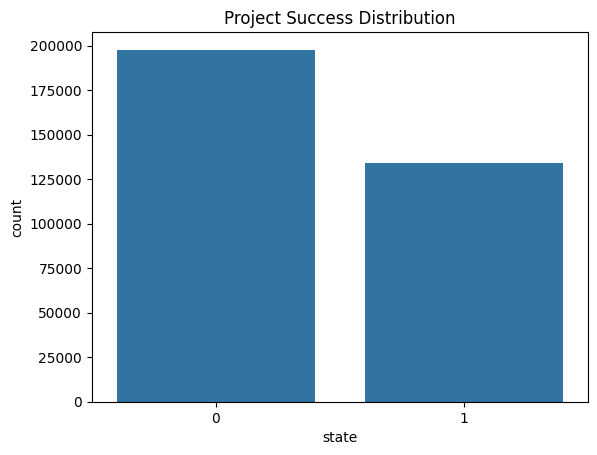

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="state", data=df)

plt.title("Project Success Distribution")
plt.show()

Как видно датасет достаточно сбалансированный по целевой переменной

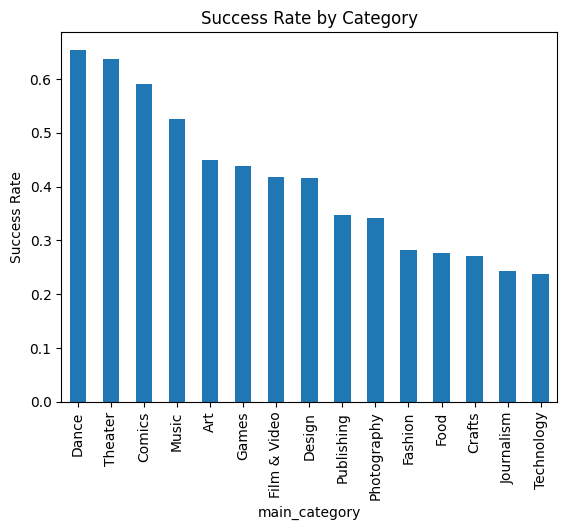

In [13]:
success_by_category = (
    df.groupby("main_category")["state"]
    .mean()
    .sort_values(ascending=False)
)

success_by_category.plot(kind="bar")

plt.title("Success Rate by Category")
plt.ylabel("Success Rate")
plt.show()

Танцы, театр, комиксы и музыка показывают высокие результаты успеха, что наводит на мысль, что творческие направление имеют больший шанс на успех.  
Технологии, еда, мода, ручное творчество и медиа проекты имеют заметно меньше шансов на успех, это можно обосновать трудностями в производстве, большими ожиданиями и высокими целями по сборам

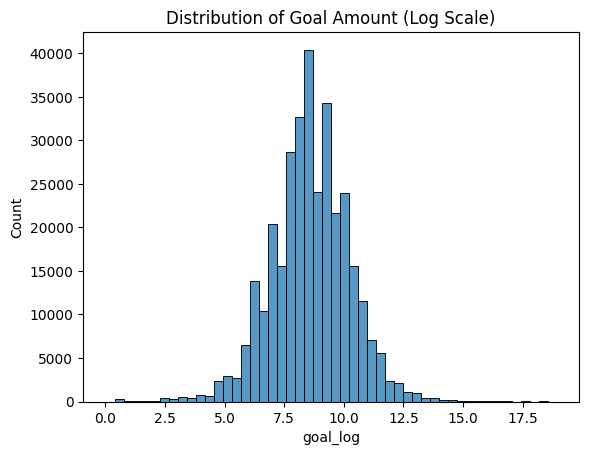

In [14]:
sns.histplot(df["goal_log"], bins=50)

plt.title("Distribution of Goal Amount (Log Scale)")
plt.show()

Видно, что большинство проектов имеют средние цели по финансированию, эктремально дорогих или очень дешевых достаточно мало

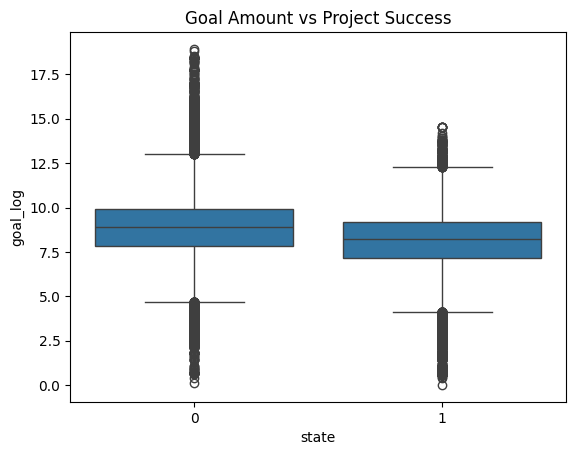

In [15]:
sns.boxplot(x="state", y="goal_log", data=df)

plt.title("Goal Amount vs Project Success")
plt.show()

По этому графику видно, что слишком огромные цели по финансированию приводят к провалу, в среднем же цели провалившихся и успешных проектов находятся на одном уровне

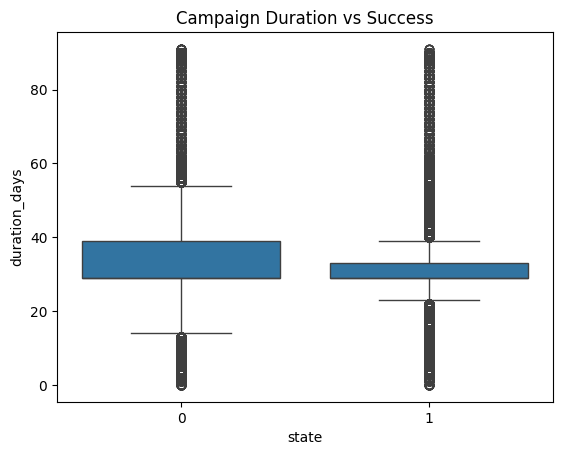

In [16]:
sns.boxplot(x="state", y="duration_days", data=df)

plt.title("Campaign Duration vs Success")
plt.show()

По этому же графику видно, что часто успешные проекты имеют немного меньшую длительность сбора, нежели провалившиеся

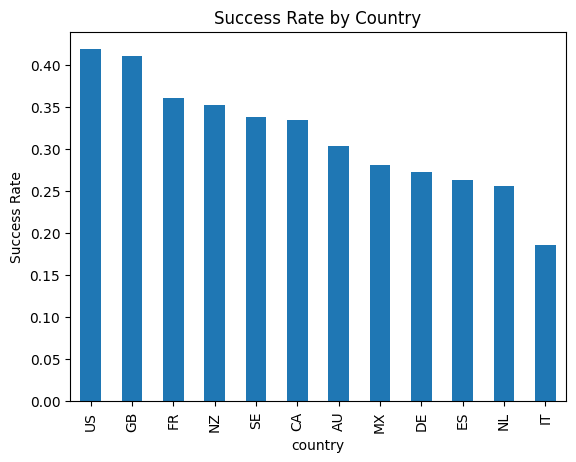

In [17]:
country_stats = df.groupby("country").agg({
    "state": ["mean", "count"]
})

country_stats.columns = ["success_rate", "project_count"]

country_stats = country_stats[
    country_stats["project_count"] > 1000
]

country_stats = country_stats.sort_values(
    "success_rate",
    ascending=False
)

country_stats["success_rate"].plot(kind="bar")

plt.title("Success Rate by Country")
plt.ylabel("Success Rate")
plt.show()

Проекты из США и Великобритании имеют больший шанс на успех, а в Италии заметно низкие, это можно объяснить заинтересованностью населения в стартапах

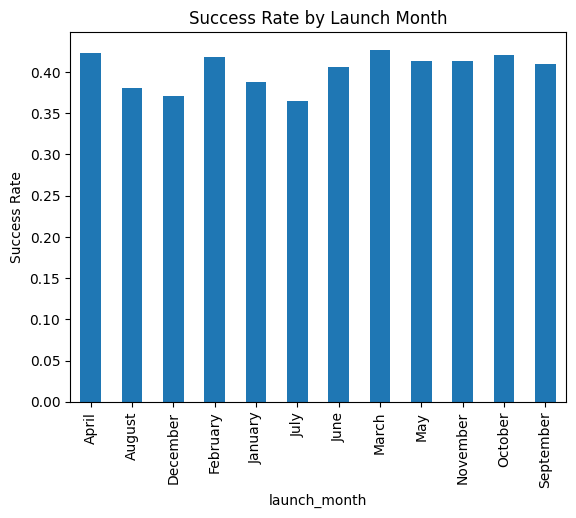

In [18]:
month_success = (
    df.groupby("launch_month")["state"]
    .mean()
)

month_success.plot(kind="bar")

plt.title("Success Rate by Launch Month")
plt.ylabel("Success Rate")
plt.show()

Здесь видно, что проекты, запущенные в августе, декабре, январе и июле проваливаются чаще, чем в другие месяцы. Это может быть связано с сезонной активностью пользователей

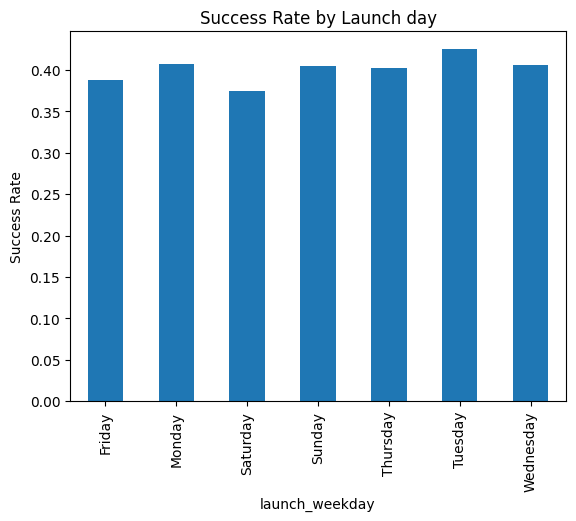

In [19]:
day_success = (
    df.groupby("launch_weekday")["state"]
    .mean()
)

day_success.plot(kind="bar")

plt.title("Success Rate by Launch day")
plt.ylabel("Success Rate")
plt.show()

По дням, в пятницу и субботу шансы уменьшаюся, а во вторник заметно выше остальных, это также можно объяснить тем, что в пятницу и субботу многие хотят отвлечься от суеты и отдохнуть, а вторник - это самый разгар рабочей недели

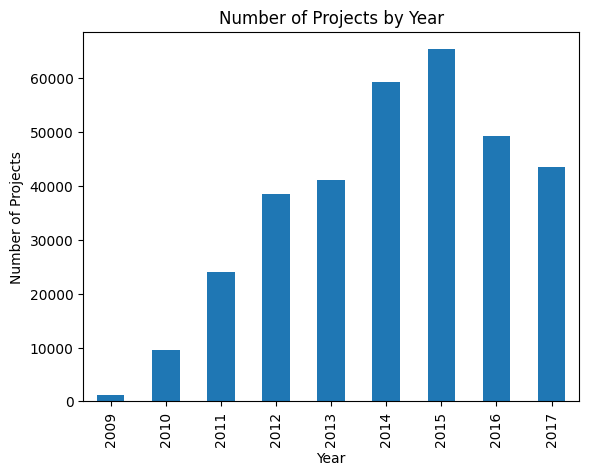

In [20]:
df["launch_year"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Projects by Year")
plt.xlabel("Year")
plt.ylabel("Number of Projects")
plt.show()

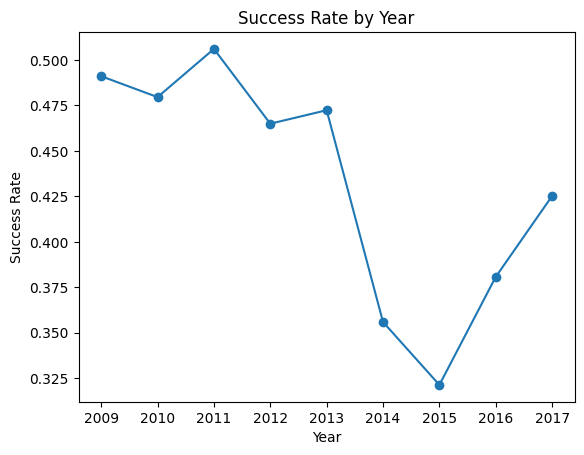

In [21]:
year_success = (
    df.groupby("launch_year")["state"]
    .mean()
)

year_success.plot(marker="o")

plt.title("Success Rate by Year")
plt.ylabel("Success Rate")
plt.xlabel("Year")
plt.show()

В некоторых случаях видна обратная зависимость количества проектов с количеством успешных, например, в 2014 и 2015 годах количество запущенных проектов значительно увеличилось, а количество успешынх сильно просело, это объясняется переполненностью для спонсоров, возможно они не могут сконцентрироваться на чем-то одном, либо же интересные проекты теряются на фоне остальных

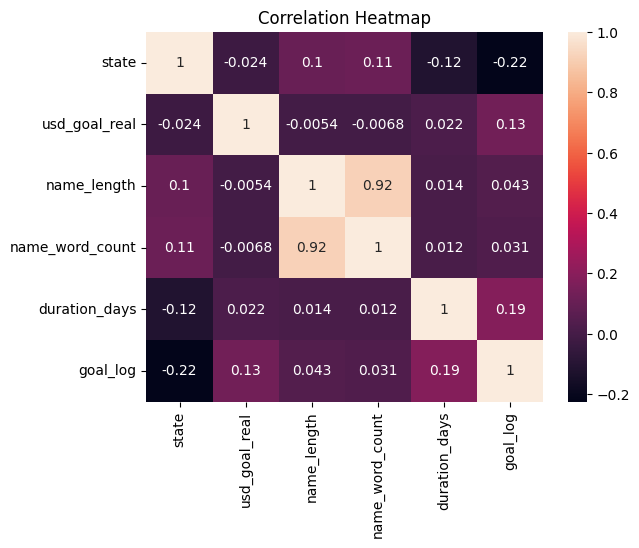

In [22]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

Корреляционный анализ показал наличие зависимости между некоторыми числовыми признаками и итоговым статусом проекта. Наиболее заметное влияние оказывают размер финансовой цели и длительность кампании. При этом сильной линейной корреляции между большинством признаков не наблюдается, что может указывать на наличие более сложных нелинейных зависимостей в данных

**Выводы**  
Проведённый EDA позволил выявить значимые закономерности и взаимосвязи между характеристиками Kickstarter-проектов и их итоговым статусом. Анализ показал, что как числовые признаки (например, размер финансирования и длительность кампании), так и категориальные признаки (категория проекта, страна запуска, сезонность) могут оказывать влияние на вероятность успеха проекта. Полученные выводы демонстрируют, что данные обладают достаточной информативностью для построения моделей для предсказания.

**Выбор моделей**

**Модели**: логистическая регрессия, randomforest и catboost  
**Метрики**: accuracy, precision, recall, f1-score

In [23]:
df.columns

Index(['category', 'main_category', 'currency', 'state', 'country',
       'usd_goal_real', 'name_length', 'name_word_count', 'duration_days',
       'launch_weekday', 'launch_month', 'launch_year', 'goal_log'],
      dtype='object')

In [24]:
df_model = df.drop(columns = [
    "usd_goal_real",
    "launch_year"
])

Логистическа регрессия

In [25]:
X = df_model.drop("state", axis=1)
y = df_model["state"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    drop_first=True
)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.70      0.80      0.75     39551
           1       0.63      0.50      0.55     26784

    accuracy                           0.68     66335
   macro avg       0.66      0.65      0.65     66335
weighted avg       0.67      0.68      0.67     66335



In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)
lr_accuracy = accuracy

print("Accuracy:", accuracy)

Accuracy: 0.6774101153237356


In [28]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    lr.predict_proba(X_test_scaled)[:,1]
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7291540856485919


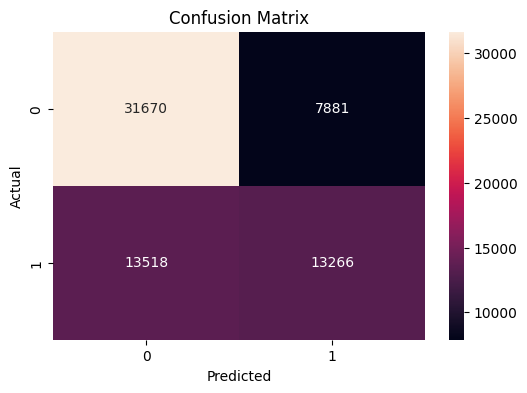

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

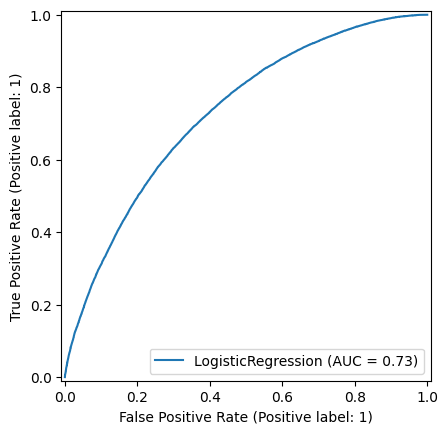

In [30]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test
)

plt.show()

Random forest

In [31]:
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = X.select_dtypes(
    include="object"
).columns

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

X_train_rf[categorical_cols] = encoder.fit_transform(
    X_train_rf[categorical_cols]
)

X_test_rf[categorical_cols] = encoder.transform(
    X_test_rf[categorical_cols]
)

In [32]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train)

rf_pred = rf.predict(X_test_rf)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.70      0.79      0.74     39551
           1       0.62      0.51      0.56     26784

    accuracy                           0.68     66335
   macro avg       0.66      0.65      0.65     66335
weighted avg       0.67      0.68      0.67     66335



In [33]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.6752543905932011


In [34]:
from sklearn.metrics import roc_auc_score

rf_roc_auc = roc_auc_score(
    y_test,
    rf.predict_proba(X_test_rf)[:,1]
)

print("ROC-AUC:", rf_roc_auc)

ROC-AUC: 0.7228968050363237


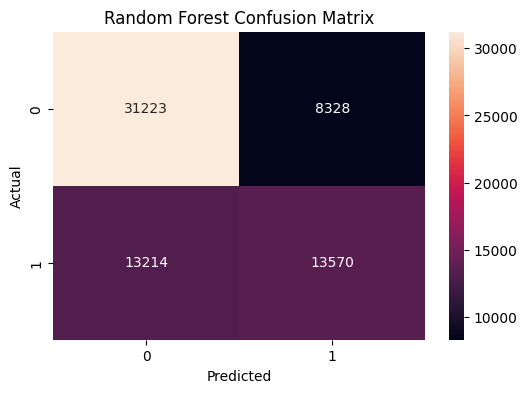

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train_rf.columns
)

top_features = importance.sort_values(
    ascending=False
).head(10)

print(top_features)

goal_log           0.205823
name_length        0.164485
category           0.131130
launch_month       0.121707
duration_days      0.101303
launch_weekday     0.087834
name_word_count    0.078707
main_category      0.072523
country            0.019133
currency           0.017354
dtype: float64


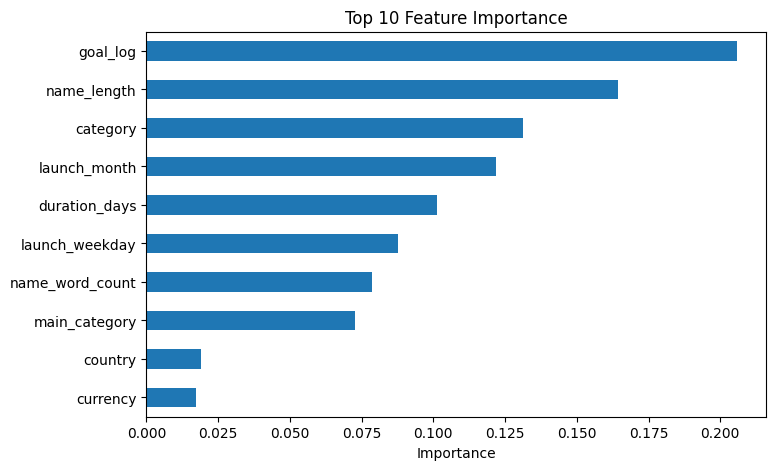

In [37]:
top_features.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")

plt.show()

Наиболее важными оказались цель по финансированию, длина названия, категория и месяц запуска

Random forest + GridSearchCV

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions={
        "n_estimators": [50, 100],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5]
    },
    n_iter=5,
    cv=2,
    scoring="f1",
    random_state=42,
    verbose=2
)

random_search.fit(
    X_train_rf,
    y_train
)

print(random_search.best_params_)

best_rf = random_search.best_estimator_

best_rf_pred = best_rf.predict(
    X_test_rf
)

print(classification_report(
    y_test,
    best_rf_pred
))


Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END max_depth=None, min_samples_split=5, n_estimators=50; total time=  13.3s
[CV] END max_depth=None, min_samples_split=5, n_estimators=50; total time=  13.0s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  29.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  28.9s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   4.9s
[CV] END .max_depth=10, min_samples_split=2, n_estimators=50; total time=   7.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  14.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  14.2s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=  22.6s
[CV] END max_depth=20, min_samples_split=2, n_estimators=100; total time=  23.9s
{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 20}
              precision    recall  f1-score   support

    

In [39]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.6752543905932011


In [40]:
from sklearn.metrics import roc_auc_score

rf_roc_auc = roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test_rf)[:,1]
)

print("ROC-AUC:", rf_roc_auc)

ROC-AUC: 0.7366817408738962


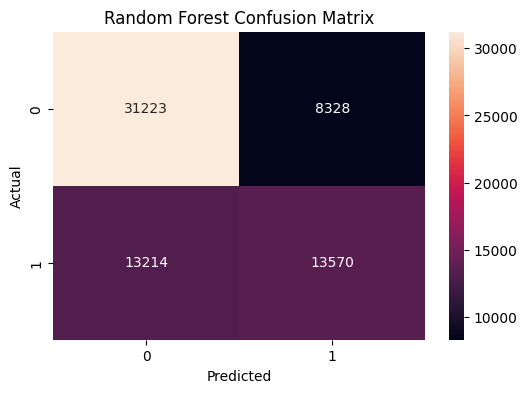

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

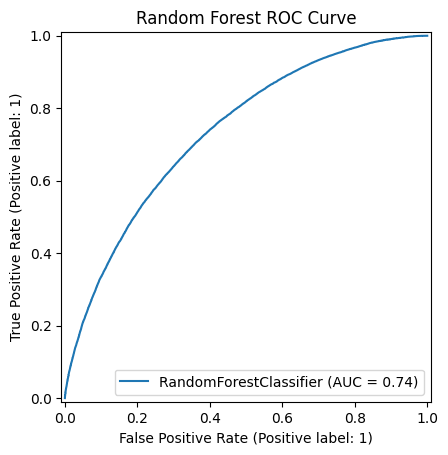

In [42]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_rf,
    X_test_rf,
    y_test
)

plt.title("Random Forest ROC Curve")

plt.show()

In [43]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train_rf.columns
)

top_features = importance.sort_values(
    ascending=False
).head(10)

print(top_features)

goal_log           0.226413
category           0.142933
name_length        0.132475
duration_days      0.126468
launch_month       0.093776
main_category      0.088828
name_word_count    0.073278
launch_weekday     0.068937
country            0.024338
currency           0.022554
dtype: float64


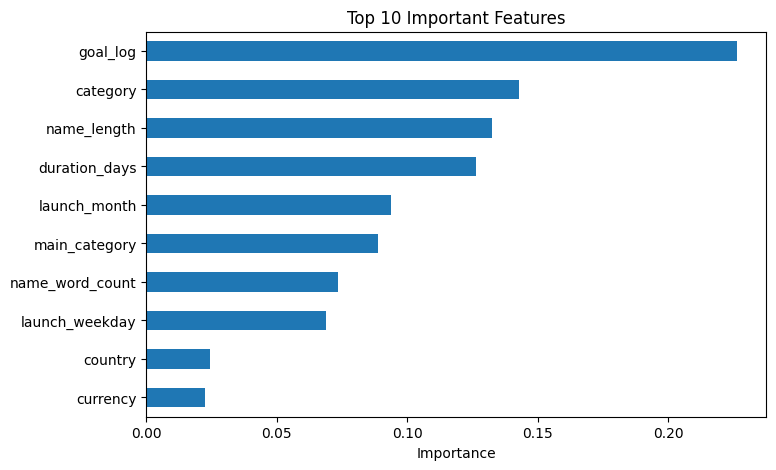

In [44]:
top_features.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()

Наиболее важными для предсказания признаками оказались цель по финансированию, подкатегория, длина названия и длительность сбора

CatBoost

In [45]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [46]:
df_cb = df_model.copy()

X = df_cb.drop("state", axis=1)
y = df_cb["state"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

cat_features = X.select_dtypes(
    include="object"
).columns.tolist()

cat_features

['category',
 'main_category',
 'currency',
 'country',
 'launch_weekday',
 'launch_month']

In [47]:
from catboost import CatBoostClassifier

In [48]:
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.1,
    depth=7,
    eval_metric="F1",
    verbose=100,
    random_state=42
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.5132792	total: 630ms	remaining: 8m 23s
100:	learn: 0.5787255	total: 1m 9s	remaining: 7m 58s
200:	learn: 0.5889974	total: 1m 58s	remaining: 5m 51s
300:	learn: 0.5940303	total: 2m 45s	remaining: 4m 34s
400:	learn: 0.5979500	total: 3m 31s	remaining: 3m 30s
500:	learn: 0.6014171	total: 4m 19s	remaining: 2m 34s
600:	learn: 0.6040172	total: 5m 10s	remaining: 1m 42s
700:	learn: 0.6069612	total: 5m 59s	remaining: 50.8s
799:	learn: 0.6097329	total: 6m 49s	remaining: 0us


CatBoostClassifier(depth=7, eval_metric='F1', iterations=800, learning_rate=0.1, random_state=42, verbose=100)

In [49]:
cat_pred = cat_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    cat_pred
))

              precision    recall  f1-score   support

           0       0.72      0.80      0.76     39551
           1       0.65      0.54      0.59     26784

    accuracy                           0.70     66335
   macro avg       0.68      0.67      0.67     66335
weighted avg       0.69      0.70      0.69     66335



In [50]:
from sklearn.metrics import accuracy_score

cat_accuracy = accuracy_score(
    y_test,
    cat_pred
)

print("Accuracy:", cat_accuracy)

Accuracy: 0.6957714630285671


In [51]:
from sklearn.metrics import roc_auc_score

cat_roc_auc = roc_auc_score(
    y_test,
    cat_model.predict_proba(X_test)[:,1]
)

print("ROC-AUC:", cat_roc_auc)

ROC-AUC: 0.7551257861845392


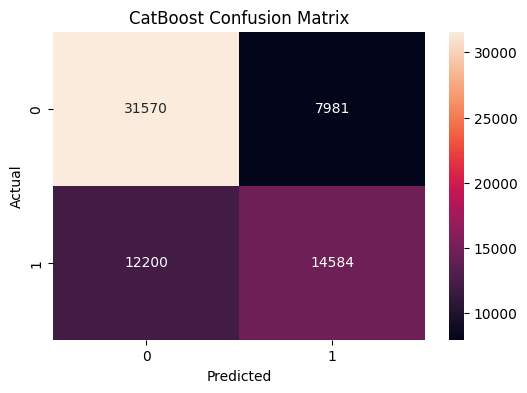

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    cat_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

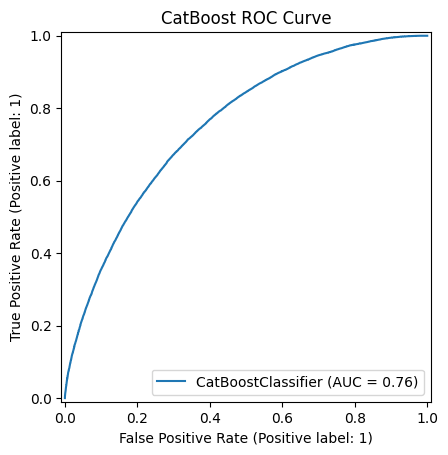

In [53]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    cat_model,
    X_test,
    y_test
)

plt.title("CatBoost ROC Curve")

plt.show()

In [54]:
importance = pd.Series(
    cat_model.get_feature_importance(),
    index=X.columns
)

top_features = importance.sort_values(
    ascending=False
).head(10)

print(top_features)

goal_log           24.354496
category           17.652578
duration_days      17.376969
main_category      14.160874
name_word_count     6.433886
name_length         6.220950
launch_month        4.534547
launch_weekday      4.020530
country             2.670458
currency            2.574714
dtype: float64


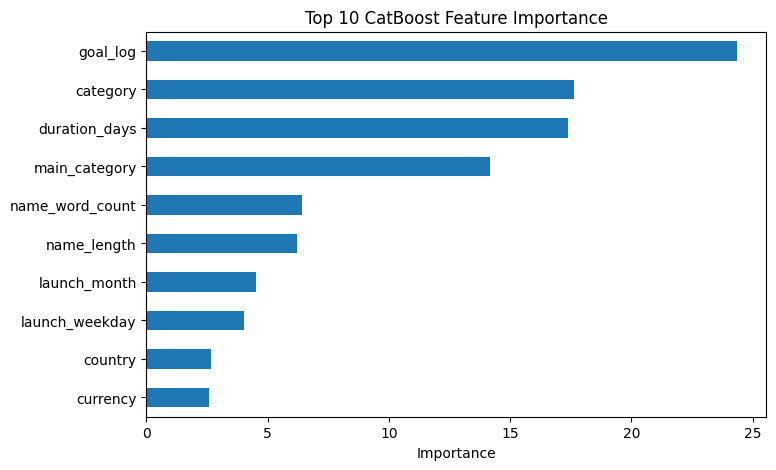

In [55]:
top_features.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 CatBoost Feature Importance")
plt.xlabel("Importance")

plt.show()

Наиболее важными признаками оказались цель по финансированию, категория, длительность сбора и основная категория

Сравнение моделей

In [56]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, y_pred)
rf_f1 = f1_score(y_test, rf_pred)
cat_f1 = f1_score(y_test, cat_pred)

In [57]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        cat_accuracy
    ],
    "F1-score": [
        lr_f1,
        rf_f1,
        cat_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        cat_roc_auc
    ]
})

comparison_df

,Model,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.677410,0.553546,0.729154
1,Random Forest,0.675254,0.557496,0.736682
2,CatBoost,0.695771,0.591056,0.755126


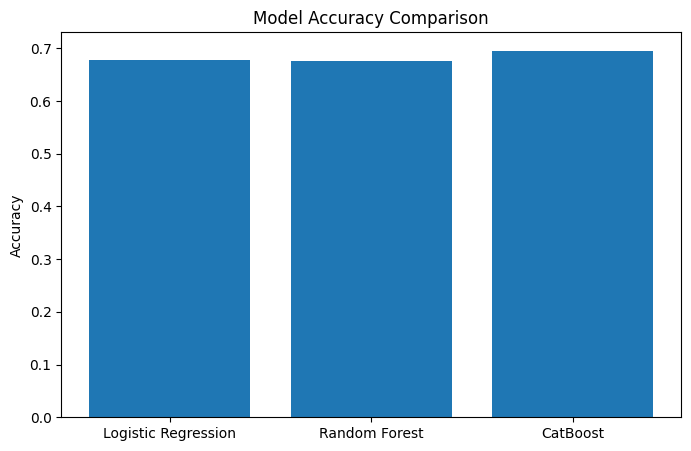

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

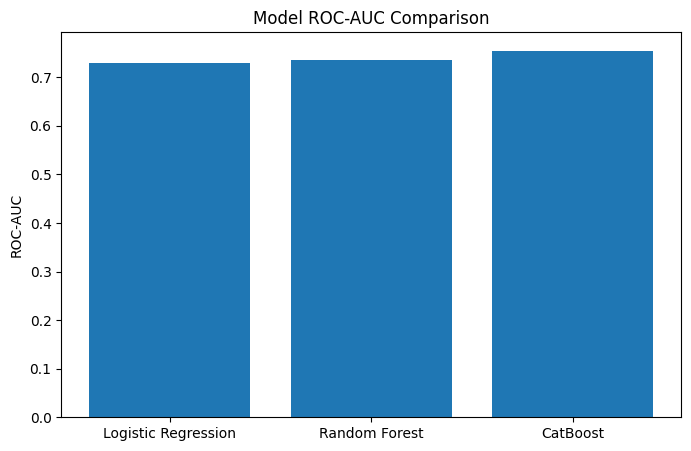

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"]
)

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")

plt.show()

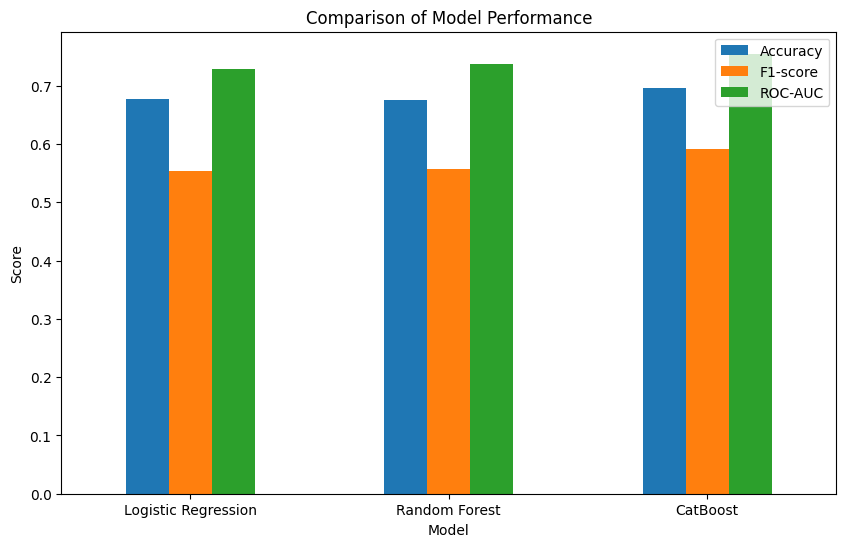

In [60]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Model Performance")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

В ходе работы был проведён разведочный анализ данных Kickstarter-проектов и построены модели машинного обучения для прогнозирования успешности компаний. В процессе исследования были выявлены факторы, потенциально влияющие на успех проекта, включая категорию, размер финансовой цели, продолжительность кампании и временные характеристики запуска.

Для решения задачи классификации были использованы модели Logistic Regression, Random Forest и CatBoost. Сравнение результатов показало, что наилучшее качество продемонстрировала модель CatBoost, достигшая максимальных значений Accuracy, F1-score и ROC-AUC. Это свидетельствует о наличии сложных нелинейных зависимостей между признаками проекта и вероятностью его успешного завершения.

Полученные результаты подтверждают возможность применения методов машинного обучения для анализа и прогнозирования успешности краудфандинговых кампаний. При этом относительно умеренные значения метрик показывают, что на успех проектов также влияют внешние факторы, отсутствующие в используемом датасете, такие как качество маркетинга, медийность проекта и активность аудитории.